In [2]:
# # create a duckdb with the df as table "theme_park_raw"

import duckdb
conn = duckdb.connect(database='theme_park_data.db')

# Creation of duckdb
# conn.execute("""CREATE TABLE theme_park_raw AS
# SELECT *
# FROM 'data.parquet';
# """)

In [3]:
data_view = conn.execute("""
    SELECT *
    FROM theme_park_database
    LIMIT 100
""").fetchdf()

data_view

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,NodeNo,FiscalDate,TranDate,CompanyID,Abbr,Name,Environment,AccountID,Qty,Amount,...,OriginalAmount,JnlDetailID,CatCode17Desc1,Last_In_Unit_Cost,Average_Unit_Cost,CatCode18Desc1,TranNo,ReceiptNo,SurveyID,Race
0,91,2023-11-11 16:00:00,2023-11-12 08:16:30,1,NaN,NaN,1,000110110101,1,0.00,...,0.00,185703107,Revenue,NaN,NaN,Group Functions-Entrance,84018,24191,<NA>,NaN
1,26,2024-12-21 16:00:00,2024-12-22 06:54:31,1,NaN,NaN,1,000110120204,1,25.00,...,25.00,221079374,Revenue,NaN,NaN,Lockers,464236,397165,<NA>,NaN
2,231,2024-07-11 16:00:00,2024-07-12 05:47:53,1,NaN,NaN,1,000153200802,0,0.00,...,0.00,199289222,NaN,NaN,NaN,NaN,70529,72634,1,Malaysia
3,201,2025-01-04 16:00:00,2025-01-05 05:23:14,10,NaN,NaN,1,001053200104,0,6.50,...,6.50,222793285,NaN,NaN,NaN,NaN,119680,213500,<NA>,NaN
4,365,2024-04-19 16:00:00,2024-04-20 08:19:11,10,NaN,NaN,1,001010210101,1,6.60,...,6.60,194274857,Revenue,NaN,NaN,F&B Kiosk,45754,253626,<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,365,2025-04-25 16:00:00,2025-04-26 05:44:13,10,NaN,NaN,1,001053200108,0,6.50,...,6.50,235634340,NaN,NaN,NaN,NaN,67362,266369,<NA>,NaN
96,314,2023-03-16 16:00:00,2023-03-17 04:51:07,1,NaN,NaN,1,000153200802,0,0.00,...,0.00,174300000,NaN,NaN,NaN,NaN,3568,203487,<NA>,NaN
97,106,2023-12-28 16:00:00,2023-12-29 04:23:48,10,NaN,NaN,1,001012000600,0,3.54,...,3.54,188278557,NaN,NaN,NaN,NaN,151504,107530,<NA>,NaN
98,35,2023-08-31 16:00:00,2023-09-01 03:27:22,1,NaN,NaN,2,000110200119,1,59.00,...,59.00,108594218,Revenue,NaN,NaN,Retail,432345,323551,<NA>,NaN


In [5]:
test = conn.execute("""select TranDate, TicketDate, AgencyName, ItemDescription, Park from theme_park_database""").fetchdf()

test

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,TranDate,TicketDate,AgencyName,ItemDescription,Park
0,2023-11-12 08:16:30.000,2023-11-19 02:37:00.000,Treasury,eLoad Group Functions,Group Function
1,2024-12-22 06:54:31.000,NaT,InPark Revenue,E-Locker,NaN
2,2024-07-12 05:47:53.000,NaT,Membership,,NaN
3,2025-01-05 05:23:14.000,NaT,Menang Pizza,,NaN
4,2024-04-20 08:19:11.000,NaT,Sunway Lagoon Kiosks,Assorted Waffle,NaN
...,...,...,...,...,...
44037381,2023-10-12 05:59:46.000,NaT,Ticketing,SD B2B MP Explorer Pass 12M New AD,NaN
44037382,2021-03-21 02:14:27.827,2021-03-21 02:14:27.827,Ticketing,Passport (12 Months),Passport
44037383,2022-07-31 05:14:03.000,NaT,Retail,Day Double Tube,NaN
44037384,2023-08-26 04:54:17.000,NaT,CFL Local Delight (Food Stall),Nasi Lemak Ayam Berempah,NaN


In [ ]:
# create a holidays table based on the holidays in theme_park_raw
conn.execute("""
     DROP TABLE IF EXISTS holidays;
     CREATE TABLE holidays AS
     SELECT
         date_trunc('day', TranDate) AS holiday_date,
         -- If multiple names exist for one date, just pick one. MAX() works well.
         MAX(HolidayName1) AS holiday_name
     FROM theme_park_database
     WHERE HolidayName1 IS NOT NULL
     GROUP BY 1; -- Group by holiday_date
 """)

# create a holidays table based on the distinct holidays in theme_park_raw
holidays = conn.execute("""
    SELECT *
    FROM holidays
    ORDER BY holiday_date ASC
""").fetchdf()

holidays

,holiday_date,holiday_name
0,2013-08-19,
1,2013-09-13,
2,2013-09-26,
3,2013-09-27,
4,2013-10-24,
...,...,...
2772,2025-10-05,
2773,2025-10-06,
2774,2025-10-07,
2775,2025-10-08,


: 

In [4]:
conn.execute("""
    DROP TABLE IF EXISTS theme_park_agg;
    CREATE TABLE IF NOT EXISTS theme_park_agg AS
        SELECT 
            CASE 
                WHEN raw.Environment = 1 THEN 'Sunway Lagoon'
                WHEN raw.Environment = 2 THEN 'Sunway Lost World of Tambun'
            END AS park_name
            , date_trunc('day', COALESCE(TicketDate, TranDate)) AS date
            , round(SUM(CASE WHEN raw.Park IS NOT NULL THEN raw.Complete_QTY ELSE 0 END), 0) as total_visitorship 
            , CASE
                -- is_open is true on any day except Tuesday, unless it's a holiday
                WHEN (dayofweek(COALESCE(TicketDate, TranDate)) <> 2) OR (hl.holiday_name IS NOT NULL AND hl.holiday_name <> '')
                THEN 1
                ELSE 0 
            END AS is_open
            , CASE
                -- is_weekend_or_holiday is true for Saturday, Sunday, or any holiday
                WHEN (dayofweek(COALESCE(TicketDate, TranDate)) in (0, 6)) OR (hl.holiday_name IS NOT NULL AND hl.holiday_name <> '')
                THEN 1
                ELSE 0
            END AS is_weekend_or_holiday
        FROM theme_park_raw raw
        LEFT JOIN holidays hl on date_trunc('day', COALESCE(TicketDate, TranDate)) = hl.holiday_date
        WHERE date_trunc('day', COALESCE(TicketDate, TranDate)) >= '2022-01-01'
        -- Group by all the columns that are not being aggregated (SUM)
        GROUP BY 
            park_name, 
            date, 
            is_open, 
            is_weekend_or_holiday
        ORDER BY 
            park_name,
            date
""")

In [5]:
theme_park_agg = conn.execute("""
    SELECT *
    FROM theme_park_agg
    ORDER BY date ASC
""").fetchdf()

theme_park_agg

,park_name,date,total_visitorship,is_open,is_weekend_or_holiday
0,Sunway Lagoon,2022-01-01,1257.0,1,1
1,Sunway Lost World of Tambun,2022-01-01,1665.0,1,1
2,Sunway Lagoon,2022-01-02,1048.0,1,1
3,Sunway Lost World of Tambun,2022-01-02,809.0,1,1
4,Sunway Lagoon,2022-01-03,550.0,1,0
...,...,...,...,...,...
2741,Sunway Lost World of Tambun,2025-10-18,0.0,1,1
2742,Sunway Lagoon,2025-10-20,22.0,1,0
2743,Sunway Lagoon,2025-10-25,0.0,1,1
2744,Sunway Lost World of Tambun,2025-10-31,0.0,1,0


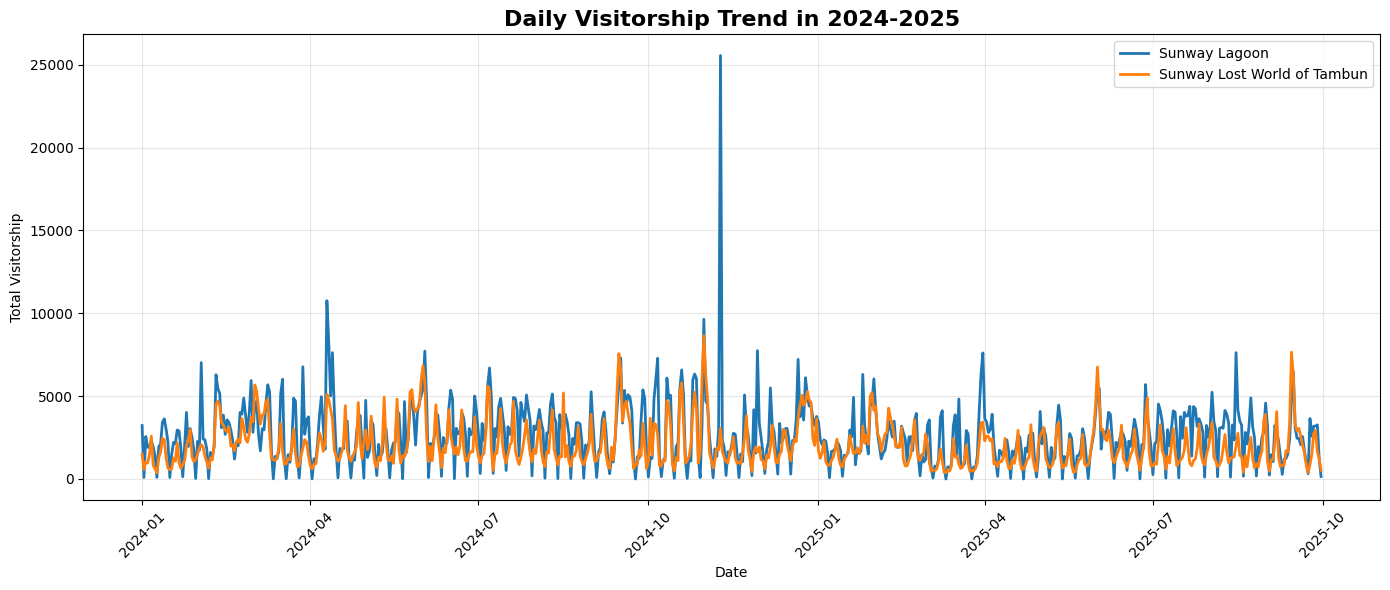

In [9]:
import matplotlib.pyplot as plt

# visitorship graph (2024 only and with the date axis properly formatted)
visitor_data = theme_park_agg[(theme_park_agg['date'] >= '2024-01-01') &
    (theme_park_agg['date'] < '2025-10-01')]
fig, ax = plt.subplots(figsize=(14, 6))
for park in visitor_data['park_name'].unique():
    park_data = visitor_data[visitor_data['park_name'] == park]
    ax.plot(park_data['date'], park_data['total_visitorship'], label=park, linewidth=2)
ax.set_xlabel('Date')
ax.set_ylabel('Total Visitorship')
ax.set_title('Daily Visitorship Trend in 2024-2025', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
visitor_data
visitor_data.to_csv("visitorship_data.csv")

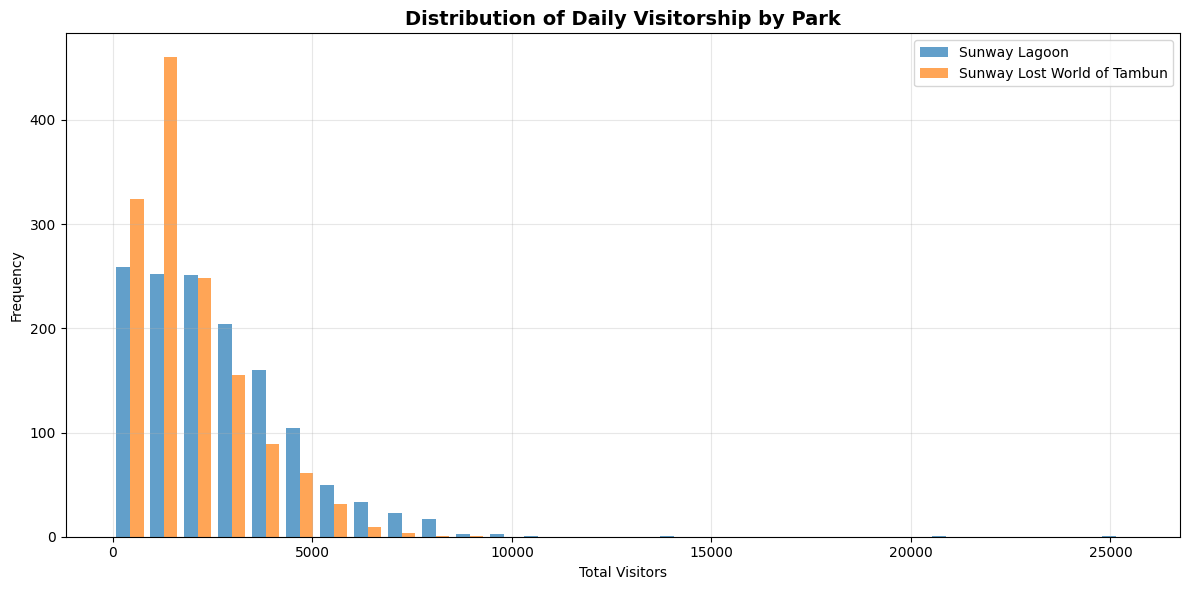

In [11]:
# Plot distribution of visitorship for both parks
plt.figure(figsize=(12, 6))

# Filter data for each park
swl_data = theme_park_agg[theme_park_agg['park_name'] == 'Sunway Lagoon']['total_visitorship']
lwot_data = theme_park_agg[theme_park_agg['park_name'] == 'Sunway Lost World of Tambun']['total_visitorship']

# Create histogram
plt.hist([swl_data, lwot_data], bins=30, alpha=0.7, label=['Sunway Lagoon', 'Sunway Lost World of Tambun'])
plt.xlabel('Total Visitors')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Visitorship by Park', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# COMPETITOR ANALYSIS DATA PROCESSING

In [228]:
import pandas as pd

# Read CASAA data
df = pd.read_excel("casaa_data.xlsx")

# Drop irrelevant columns
drop_cols = ["prompt_token_count", "output_token_count", "cost_incur", 
             "likes", "comments_no", "shares", "distance_to_lagoon_km", "distance_to_tambun_km"]
df = df.drop(columns=drop_cols)

filtered_df = df.copy()

# Keep only promotional rows with competitive advantage
filtered_df = df[
    (~df["category"].isin(["Non-Promotional", "Awareness-Promo", "Price-Promo (Untimed)"])) &
    (df["competitive_advantage_type"].notna()) &
    (df["competitive_advantage_type"] != "Permanent") &
    (df["post_creation_date"] >= "2024-01-01")
]

# filter awareness-promo with temporary or seasonal advantage
# filtered_df = filtered_df[~((filtered_df["category"] == "Awareness-Promo") &
#     (filtered_df["competitive_advantage_type"].isin(["Temporary", "Seasonal"])))
# ]

# sort by start date
filtered_df = filtered_df.sort_values(by="start_date")

# remove those that start date is before the post creation date
filtered_df = filtered_df[filtered_df["start_date"] >= filtered_df["post_creation_date"]]

# Create boolean mask for Sunway vs competitor
is_sunway = filtered_df["competitor_name"].str.contains("Sunway", case=False, na=False)

sunway_df = filtered_df[is_sunway]
competitor_df = filtered_df[~is_sunway]

print(f"Total filtered rows: {len(filtered_df)}")
print(f"Sunway Posts: {len(sunway_df)}")
print(f"Competitor Posts: {len(competitor_df)}")

Total filtered rows: 155
Sunway Posts: 14
Competitor Posts: 141


In [229]:
competitor_df

,competitor_name,post_creation_date,post_content,category,competitive_advantage_type,start_date,end_date,engagement_score,competitor_score,distance_lagoon_exp_weight,distance_tambun_exp_weight
603,Escape Ipoh,2024-04-03,Promosi Raya: 25% diskaun ekstra dengan kod pr...,Price-Promo (Timed),Temporary,2024-04-03,2024-04-30,4147,3,0.085804,0.652165
875,I-City Leisure,2024-04-16,Celebrate Hari Raya with Race Karting i-City E...,Price-Promo (Timed),Seasonal,2024-04-16,2024-05-05,5,5,0.814501,0.065096
79,A'Famosa Resort,2024-04-22,RAYA KAN SEBULAN Masih tercari cari dewan deng...,Price-Promo (Timed),Seasonal,2024-04-23,2024-05-07,29,4,0.225071,0.015815
1208,Melaka Wonderland Theme Park & Resort,2024-04-24,TERIMA KASIH ATAS KENANGAN YANG DIKONGSIKAN BE...,Price-Promo (Timed),Temporary,2024-04-24,2024-04-24,8,4,0.165507,0.011496
874,I-City Leisure,2024-04-26,i-City Theme Park is back with some incredible...,Price-Promo (Timed),Temporary,2024-04-26,2024-04-28,1,5,0.814501,0.065096
...,...,...,...,...,...,...,...,...,...,...,...
268,Bangi Wonderland,2025-09-07,Can buy at this link https://bangiwonderland-o...,Price-Promo (Timed),Temporary,2025-09-07,2025-09-08,145,5,0.649506,0.043133
1121,LEGOLAND Malaysia,2025-09-08,BIG LEGOÂ® DEALS ARE HERE! From 8 September 20...,Price-Promo (Timed),Temporary,2025-09-08,2025-10-05,21,5,0.011540,0.000984
185,Adventure Waterpark Desaru Coast,2025-09-08,Couldnâ€™t attend Matta Fair KL? No problem! W...,Price-Promo (Timed),Temporary,2025-09-08,2025-09-08,94,3,0.005233,0.000555
1746,SplashMania,2025-09-08,Missed out visiting our GL Play booth at MATTA...,Price-Promo (Timed),Temporary,2025-09-08,2025-09-12,3,5,0.733256,0.046003


In [230]:
sunway_df

,competitor_name,post_creation_date,post_content,category,competitive_advantage_type,start_date,end_date,engagement_score,competitor_score,distance_lagoon_exp_weight,distance_tambun_exp_weight
1937,"Sunway Lagoon, Malaysia",2024-05-09,Ready to elevate your shopping experience? Mar...,Price-Promo (Timed),Temporary,2024-05-11,2024-05-11,70,0,NaN,NaN
2083,Sunway Lost World Of Tambun,2024-05-10,"ON YOUR CART, GET SET, SHOP! Get your #Awesome...",Price-Promo (Timed),Temporary,2024-05-11,2024-05-11,26,0,NaN,NaN
1938,"Sunway Lagoon, Malaysia",2024-06-05,Sunway Theme Parks promotions are just around ...,Price-Promo (Timed),Temporary,2024-06-07,2024-06-09,57,0,NaN,NaN
1940,"Sunway Lagoon, Malaysia",2024-08-04,Did you hear? We're releasing another batch of...,Price-Promo (Timed),Temporary,2024-08-04,2024-08-04,26,0,NaN,NaN
1941,"Sunway Lagoon, Malaysia",2024-09-05,PART TWO of all the #BestDayEver and #BestStay...,Price-Promo (Timed),Temporary,2024-09-06,2024-09-08,257,0,NaN,NaN
2085,Sunway Lost World Of Tambun,2024-09-05,Capture your #AwesomeMoments from all the unbe...,Price-Promo (Timed),Temporary,2024-09-06,2024-09-08,118,0,NaN,NaN
1942,"Sunway Lagoon, Malaysia",2024-09-28,Sunway Lagoon is coming to Sunway University O...,Price-Promo (Timed),Temporary,2024-09-30,2024-09-30,76,0,NaN,NaN
2086,Sunway Lost World Of Tambun,2024-10-23,Celebrate Halloween with spooky savings! Don't...,Price-Promo (Timed),Seasonal,2024-10-26,2024-10-27,0,0,NaN,NaN
1943,"Sunway Lagoon, Malaysia",2024-10-31,Planning some Selangor adventures? Sunway Lago...,Price-Promo (Timed),Temporary,2024-11-01,2024-11-03,0,0,NaN,NaN
2089,Sunway Lost World Of Tambun,2024-12-21,Ding dong FREE ENTRY for our Lost World Hot S...,Price-Promo (Timed),Seasonal,2024-12-24,2024-12-25,29,0,NaN,NaN


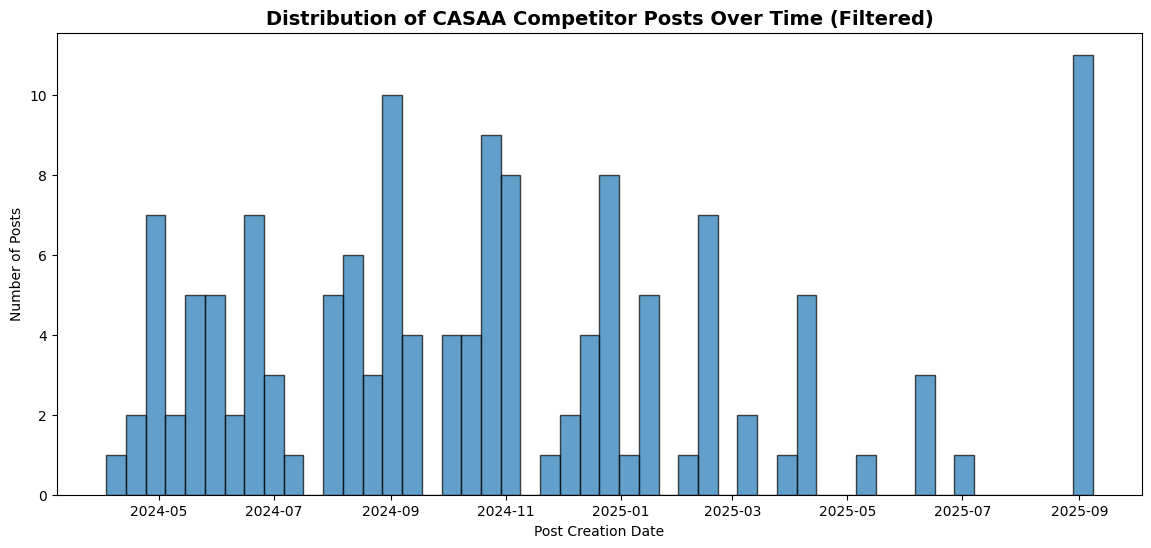

In [231]:
# show the graph of post counts over time (histogram)
plt.figure(figsize=(14, 6))
plt.hist(pd.to_datetime(competitor_df['post_creation_date']), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Post Creation Date')
plt.ylabel('Number of Posts')
plt.title('Distribution of CASAA Competitor Posts Over Time (Filtered)', fontsize=14, fontweight='bold')
plt.show()

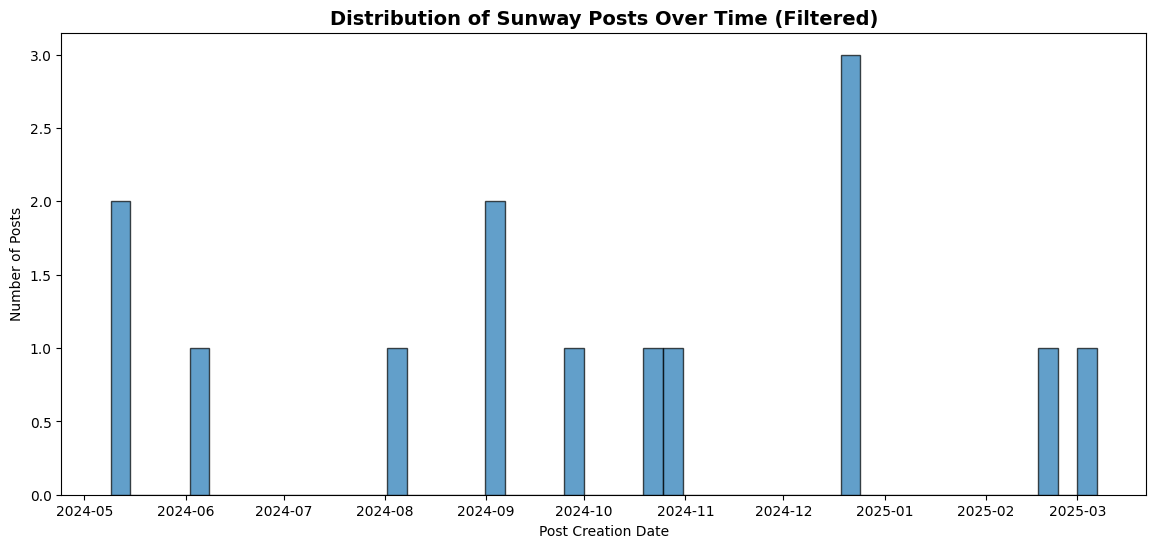

In [232]:
# show the graph of sunway post counts over time (histogram)
plt.figure(figsize=(14, 6))
plt.hist(pd.to_datetime(sunway_df['post_creation_date']), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Post Creation Date')
plt.ylabel('Number of Posts')
plt.title('Distribution of Sunway Posts Over Time (Filtered)', fontsize=14, fontweight='bold')
plt.show()

c:\Users\edmundcyk\Desktop\projects\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\edmundcyk\Desktop\projects\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


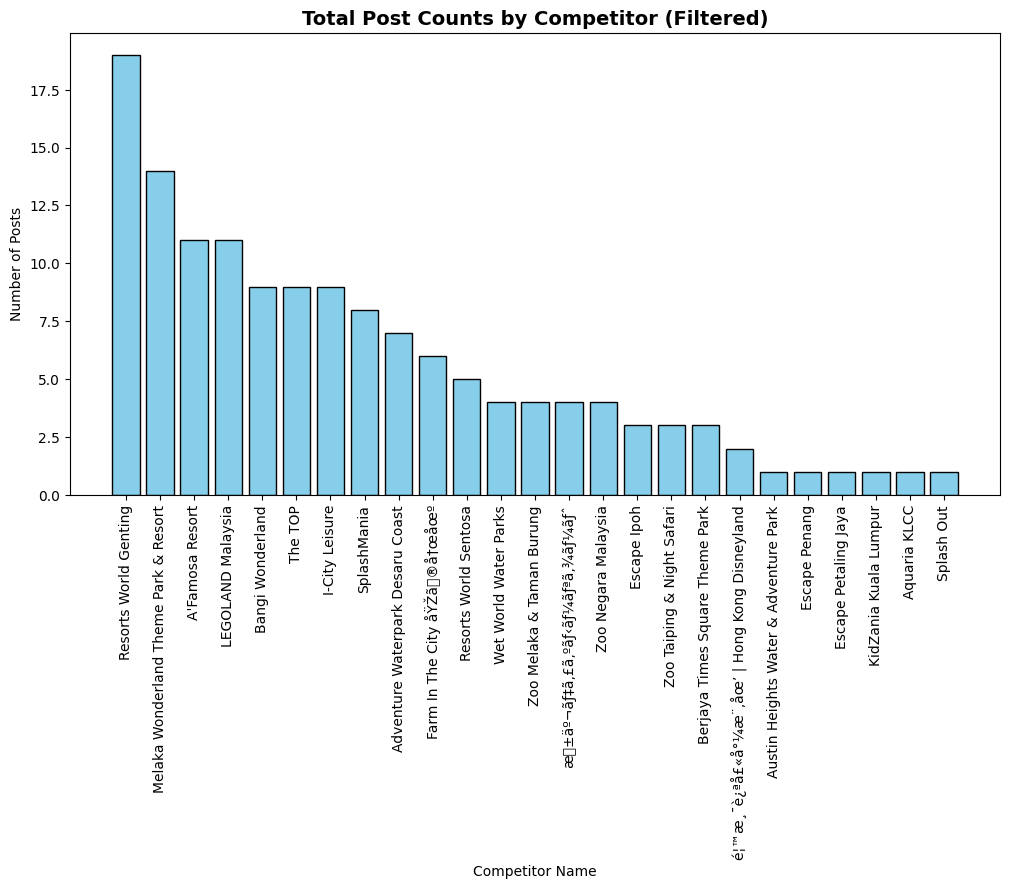

In [233]:
# show histogram of total post counts of each competitor
plt.figure(figsize=(12, 6))
competitor_counts = competitor_df['competitor_name'].value_counts()
plt.bar(competitor_counts.index, competitor_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Competitor Name')
plt.ylabel('Number of Posts')
plt.title('Total Post Counts by Competitor (Filtered)', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

In [234]:
# Expand each promotion to one row per active date

expanded_rows = []
for _, row in competitor_df.iterrows():
    start_date = pd.to_datetime(row['start_date'])
    end_date = pd.to_datetime(row['end_date'])
    if pd.isna(start_date) or pd.isna(end_date):
        continue
    current_date = max(start_date, pd.to_datetime('2024-01-01'))
    while current_date <= end_date:
        new_row = row.copy()
        new_row['active_date'] = current_date
        expanded_rows.append(new_row)
        current_date += pd.Timedelta(days=1)

casaa_daily_df = pd.DataFrame(expanded_rows)


In [235]:
casaa_daily_df

,competitor_name,post_creation_date,post_content,category,competitive_advantage_type,start_date,end_date,engagement_score,competitor_score,distance_lagoon_exp_weight,distance_tambun_exp_weight,active_date
603,Escape Ipoh,2024-04-03,Promosi Raya: 25% diskaun ekstra dengan kod pr...,Price-Promo (Timed),Temporary,2024-04-03,2024-04-30,4147,3,0.085804,0.652165,2024-04-03
603,Escape Ipoh,2024-04-03,Promosi Raya: 25% diskaun ekstra dengan kod pr...,Price-Promo (Timed),Temporary,2024-04-03,2024-04-30,4147,3,0.085804,0.652165,2024-04-04
603,Escape Ipoh,2024-04-03,Promosi Raya: 25% diskaun ekstra dengan kod pr...,Price-Promo (Timed),Temporary,2024-04-03,2024-04-30,4147,3,0.085804,0.652165,2024-04-05
603,Escape Ipoh,2024-04-03,Promosi Raya: 25% diskaun ekstra dengan kod pr...,Price-Promo (Timed),Temporary,2024-04-03,2024-04-30,4147,3,0.085804,0.652165,2024-04-06
603,Escape Ipoh,2024-04-03,Promosi Raya: 25% diskaun ekstra dengan kod pr...,Price-Promo (Timed),Temporary,2024-04-03,2024-04-30,4147,3,0.085804,0.652165,2024-04-07
...,...,...,...,...,...,...,...,...,...,...,...,...
1122,LEGOLAND Malaysia,2025-09-08,"Less hassle, more playtime!Annual Passholders ...",Price-Promo (Timed),Temporary,2025-09-08,2025-12-31,16,5,0.011540,0.000984,2025-12-27
1122,LEGOLAND Malaysia,2025-09-08,"Less hassle, more playtime!Annual Passholders ...",Price-Promo (Timed),Temporary,2025-09-08,2025-12-31,16,5,0.011540,0.000984,2025-12-28
1122,LEGOLAND Malaysia,2025-09-08,"Less hassle, more playtime!Annual Passholders ...",Price-Promo (Timed),Temporary,2025-09-08,2025-12-31,16,5,0.011540,0.000984,2025-12-29
1122,LEGOLAND Malaysia,2025-09-08,"Less hassle, more playtime!Annual Passholders ...",Price-Promo (Timed),Temporary,2025-09-08,2025-12-31,16,5,0.011540,0.000984,2025-12-30


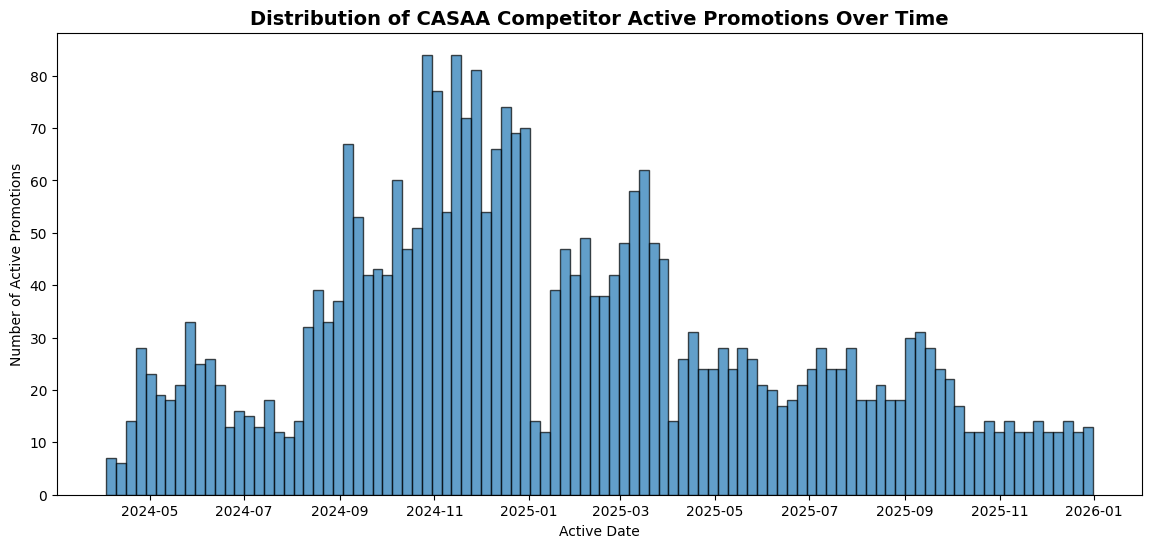

In [236]:
# visualize the casaa_daily_df in graph to see daily promotion counts
plt.figure(figsize=(14, 6))
plt.hist(pd.to_datetime(casaa_daily_df['active_date']), bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Active Date')
plt.ylabel('Number of Active Promotions')
plt.title('Distribution of CASAA Competitor Active Promotions Over Time', fontsize=14, fontweight='bold')
plt.show()

In [237]:
import numpy as np

# time decay weight for promo period
casaa_daily_df['t_since_start'] = (
    (casaa_daily_df['active_date'] - pd.to_datetime(casaa_daily_df['start_date'])).dt.days.clip(lower=0)
)

lambda_ = 0.15
casaa_daily_df['time_decay_weight'] = np.exp(-lambda_ * casaa_daily_df['t_since_start'])

# First, create separate influence scores for each park in the expanded competitor dataframe
casaa_daily_df['lagoon_influence_score'] = (
    casaa_daily_df['engagement_score'] * 
    casaa_daily_df['competitor_score'] * 
    casaa_daily_df['distance_lagoon_exp_weight'] *
    casaa_daily_df['time_decay_weight']
)

casaa_daily_df['tambun_influence_score'] = (
    casaa_daily_df['engagement_score'] * 
    casaa_daily_df['competitor_score'] * 
    casaa_daily_df['distance_tambun_exp_weight'] *
    casaa_daily_df['time_decay_weight']
)

# Now, group by date to get a total daily influence score and count of active promotions
competitor_daily_summary = casaa_daily_df.groupby('active_date').agg(
    total_lagoon_influence=('lagoon_influence_score', 'sum'),
    total_tambun_influence=('tambun_influence_score', 'sum'),
    active_promo_count=('competitor_name', 'count')  # Count of active promotions on that day
).reset_index()

# Rename 'active_date' to 'date' for merging
competitor_daily_summary.rename(columns={'active_date': 'date'}, inplace=True)

print("Competitor Daily Summary:")
competitor_daily_summary

Competitor Daily Summary:


,date,total_lagoon_influence,total_tambun_influence,active_promo_count
0,2024-04-03,1.067494e+03,8.113588e+03,1
1,2024-04-04,9.188003e+02,6.983430e+03,1
2,2024-04-05,7.908188e+02,6.010694e+03,1
3,2024-04-06,6.806640e+02,5.173452e+03,1
4,2024-04-07,5.858530e+02,4.452831e+03,1
...,...,...,...,...
632,2025-12-27,6.301527e-08,5.372632e-09,2
633,2025-12-28,5.423775e-08,4.624267e-09,2
634,2025-12-29,4.668286e-08,3.980144e-09,2
635,2025-12-30,4.018031e-08,3.425742e-09,2


In [ ]:
# Ensure the 'date' column in theme_park_agg is datetime
visitor_data['date'] = pd.to_datetime(visitor_data['date'])

# Perform a left merge to keep all park data, even on days with no competitor activity
master_df = pd.merge(
    visitor_data,
    competitor_daily_summary,
    on='date',
    how='left'
)
# Create a final 'competitor_influence' column based on the park name
master_df['competitor_influence'] = master_df.apply(
    lambda row: row['total_lagoon_influence'] if row['park_name'] == 'Sunway Lagoon' else row['total_tambun_influence'],
    axis=1
)

# min max scale competitor_influence column
min_influence = master_df['competitor_influence'].min()
max_influence = master_df['competitor_influence'].max()
master_df['competitor_influence'] = (
    (master_df['competitor_influence'] - min_influence) /
    (max_influence - min_influence)
)

# Fill NaNs for days with no promotions and drop helper columns
master_df['competitor_influence'].fillna(0, inplace=True)
master_df['active_promo_count'].fillna(0, inplace=True)
master_df.drop(columns=['total_lagoon_influence', 'total_tambun_influence'], inplace=True)

print("\nMaster DataFrame:")
master_df


Master DataFrame:


C:\Users\edmundcyk\AppData\Local\Temp\ipykernel_10528\1895249359.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  visitor_data['date'] = pd.to_datetime(visitor_data['date'])
C:\Users\edmundcyk\AppData\Local\Temp\ipykernel_10528\1895249359.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

,park_name,date,total_visitorship,is_open,is_weekend_or_holiday,active_promo_count,competitor_influence
0,Sunway Lagoon,2024-01-01,3225.0,1,1,0.0,0.000000
1,Sunway Lost World of Tambun,2024-01-01,1496.0,1,1,0.0,0.000000
2,Sunway Lagoon,2024-01-02,90.0,0,0,0.0,0.000000
3,Sunway Lost World of Tambun,2024-01-02,582.0,0,0,0.0,0.000000
4,Sunway Lagoon,2024-01-03,2565.0,1,0,0.0,0.000000
...,...,...,...,...,...,...,...
727,Sunway Lost World of Tambun,2024-12-29,2435.0,1,1,14.0,0.001229
728,Sunway Lagoon,2024-12-30,3229.0,1,0,12.0,0.009147
729,Sunway Lost World of Tambun,2024-12-30,2027.0,1,0,12.0,0.000618
730,Sunway Lagoon,2024-12-31,3774.0,1,1,11.0,0.007873


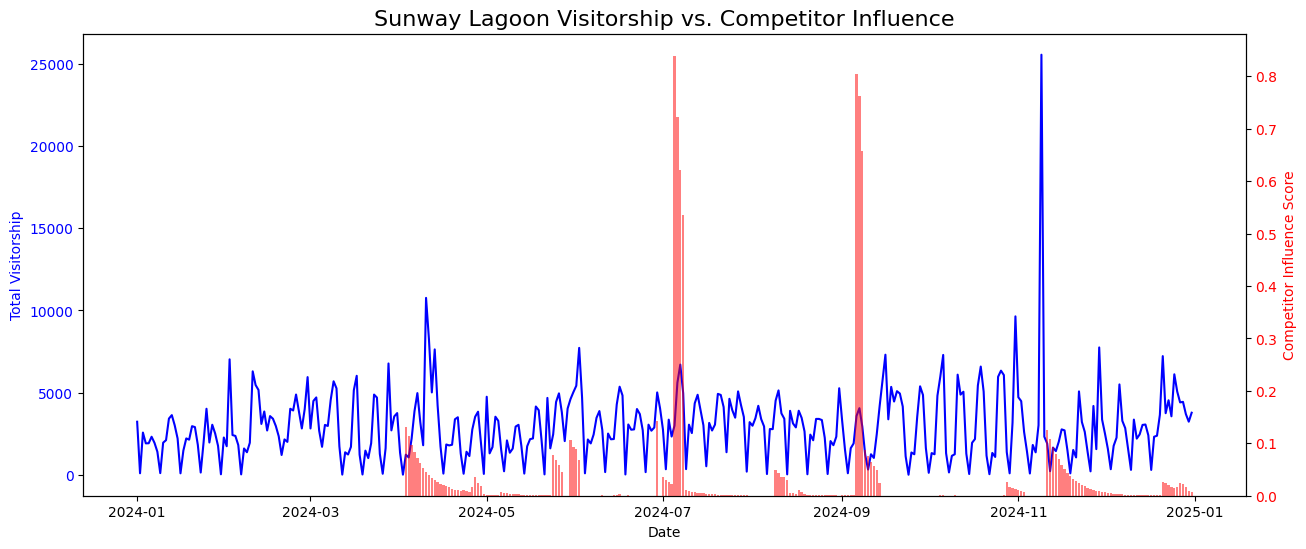

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate data for each park for cleaner plots
lagoon_data = master_df[master_df['park_name'] == 'Sunway Lagoon']
tambun_data = master_df[master_df['park_name'] == 'Sunway Lost World of Tambun']

# Plot for Sunway Lagoon
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(lagoon_data['date'], lagoon_data['total_visitorship'], color='blue', label='Lagoon Visitorship')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Visitorship', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.bar(lagoon_data['date'], lagoon_data['competitor_influence'], color='red', alpha=0.5, label='Competitor Influence Score')
ax2.set_ylabel('Competitor Influence Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Sunway Lagoon Visitorship vs. Competitor Influence', fontsize=16)
plt.show()


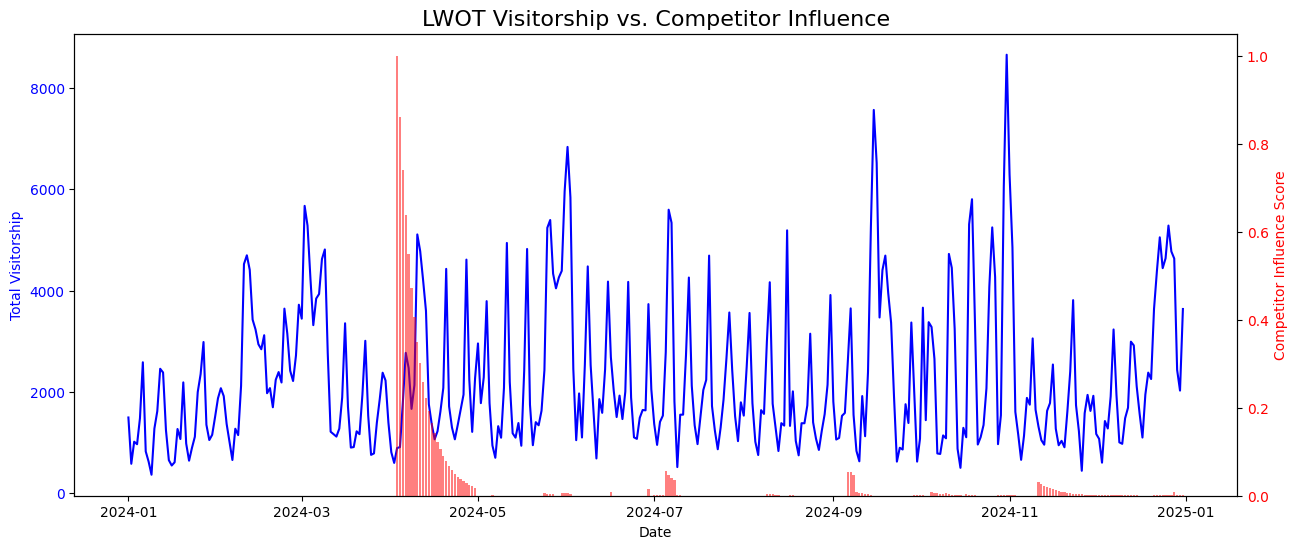

In [242]:
# Plot for Sunway Lagoon
fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(tambun_data['date'], tambun_data['total_visitorship'], color='blue', label='LWOT Visitorship')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Visitorship', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.bar(tambun_data['date'], tambun_data['competitor_influence'], color='red', alpha=0.5, label='Competitor Influence Score')
ax2.set_ylabel('Competitor Influence Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('LWOT Visitorship vs. Competitor Influence', fontsize=16)
plt.show()

--- Sunway Lagoon Correlation Matrix ---


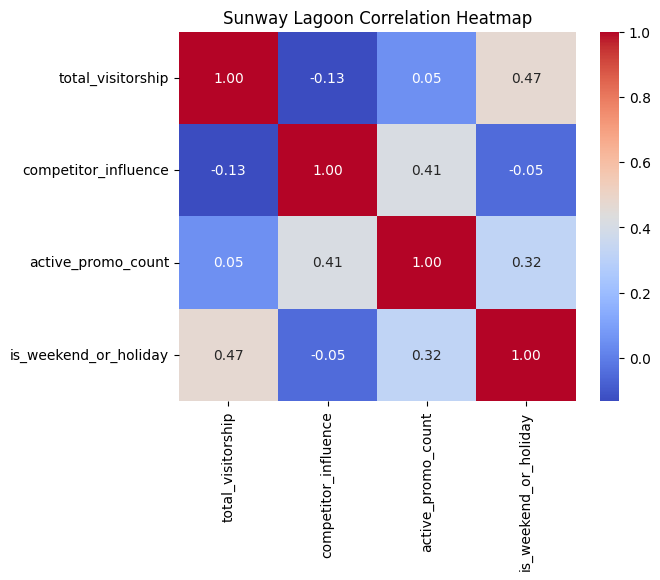


--- Sunway Lost World of Tambun Correlation Matrix ---


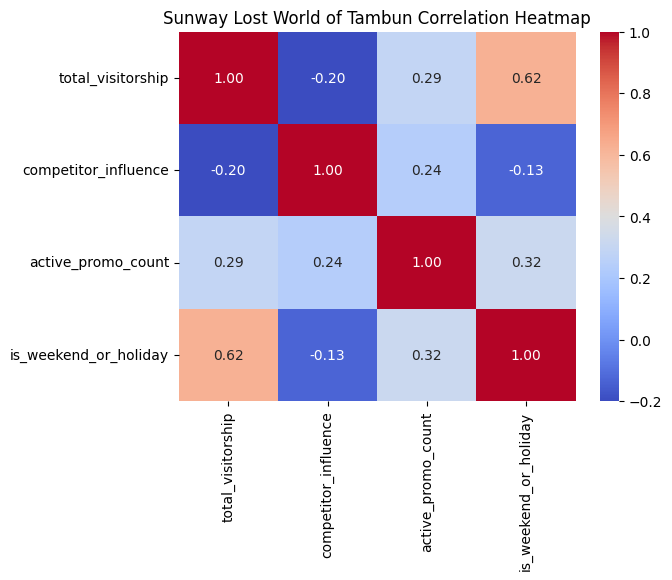

In [174]:
# We'll analyze each park separately
print("--- Sunway Lagoon Correlation Matrix ---")
lagoon_corr = lagoon_data[['total_visitorship', 'competitor_influence', 'active_promo_count', 'is_weekend_or_holiday']].corr()
sns.heatmap(lagoon_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sunway Lagoon Correlation Heatmap')
plt.show()

print("\n--- Sunway Lost World of Tambun Correlation Matrix ---")
tambun_corr = tambun_data[['total_visitorship', 'competitor_influence', 'active_promo_count', 'is_weekend_or_holiday']].corr()
sns.heatmap(tambun_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sunway Lost World of Tambun Correlation Heatmap')
plt.show()

In [ ]:
# Group the expanded dataframe by competitor name and sum their total influence scores
competitor_ranking_lagoon = casaa_daily_df.groupby('competitor_name')['lagoon_influence_score'].sum().sort_values(ascending=False)
competitor_ranking_tambun = casaa_daily_df.groupby('competitor_name')['tambun_influence_score'].sum().sort_values(ascending=False)

print("--- Top 10 Most Influential Competitors for Sunway Lagoon ---")
print(competitor_ranking_lagoon.head(10))

print("\n--- Top 10 Most Influential Competitors for Sunway Lost World of Tambun ---")
print(competitor_ranking_tambun.head(10))

--- Top 10 Most Influential Competitors for Sunway Lagoon ---
competitor_name
Bangi Wonderland                   323627.081249
Escape Ipoh                          7705.551384
KidZania Kuala Lumpur                6372.405778
SplashMania                          5327.257591
Zoo Negara Malaysia                  4292.229906
A'Famosa Resort                      2827.301421
Berjaya Times Square Theme Park      1667.304344
Farm In The City åŸŽã®å†œåœº        1470.985272
Escape Petaling Jaya                  809.535531
I-City Leisure                        727.487978
Name: lagoon_influence_score, dtype: float64

--- Top 10 Most Influential Competitors for Sunway Lost World of Tambun ---
competitor_name
Escape Ipoh                        58566.778295
Bangi Wonderland                   21491.575904
The TOP                             1158.268963
KidZania Kuala Lumpur                533.333181
Zoo Negara Malaysia                  441.600368
SplashMania                          334.223662
A'Famo

In [ ]:
# Identify days with low visitorship (e.g., below the 25th percentile) for Sunway Lagoon
low_visitor_threshold = lagoon_data['total_visitorship'].quantile(0.25)
low_visitor_days = lagoon_data[lagoon_data['total_visitorship'] < low_visitor_threshold]['date']

# Filter the expanded competitor data to only these low-visitor days
competitors_on_low_days = casaa_daily_df[casaa_daily_df['active_date'].isin(low_visitor_days)]

# Find out which competitors had the highest total influence on these specific days
culprit_ranking = competitors_on_low_days.groupby('competitor_name')['lagoon_influence_score'].sum().sort_values(ascending=False)

print(f"\n--- Top Competitors Active During Sunway Lagoon's Low Visitorship Days ---")
print(culprit_ranking.head(10))

low_visitor_threshold = tambun_data['total_visitorship'].quantile(0.25)
low_visitor_days = tambun_data[tambun_data['total_visitorship'] < low_visitor_threshold]['date']

# Filter the expanded competitor data to only these low-visitor days
competitors_on_low_days = casaa_daily_df[casaa_daily_df['active_date'].isin(low_visitor_days)]

# Find out which competitors had the highest total influence on these specific days
culprit_ranking = competitors_on_low_days.groupby('competitor_name')['tambun_influence_score'].sum().sort_values(ascending=False)

print(f"\n--- Top Competitors Active During LWOT's Low Visitorship Days ---")
print(culprit_ranking.head(10))


--- Top Competitors Active During Sunway Lagoon's Low Visitorship Days ---
competitor_name
KidZania Kuala Lumpur                    1371.801681
Escape Petaling Jaya                      174.270478
A'Famosa Resort                           130.239878
Escape Ipoh                                31.413277
The TOP                                    14.966582
Zoo Taiping & Night Safari                  1.755454
Escape Penang                               1.163221
Melaka Wonderland Theme Park & Resort       0.320616
Adventure Waterpark Desaru Coast            0.305649
LEGOLAND Malaysia                           0.190003
Name: lagoon_influence_score, dtype: float64

--- Top Competitors Active During LWOT's Low Visitorship Days ---
competitor_name
Escape Ipoh                         447.307158
KidZania Kuala Lumpur               202.864984
The TOP                             188.437948
Escape Penang                        27.128997
Escape Petaling Jaya                 21.732297
Zoo Taiping & N

In [ ]:
# Isolate the high-influence period
q1_2025_competitors = casaa_daily_df[
    (casaa_daily_df['active_date'] >= '2025-01-01') & 
    (casaa_daily_df['active_date'] <= '2025-03-31')
]

# Rank competitors by their influence score *during this specific period*
q1_culprit_ranking = q1_2025_competitors.groupby('competitor_name')['lagoon_influence_score'].sum().sort_values(ascending=False)

print("--- Top Competitors Responsible for the Q1 2025 Influence Spike ---")
print(q1_culprit_ranking.head(5))

# Now, examine the type of promotions they were running
print("\n--- Promotion Types During Q1 2025 Spike ---")
print(q1_2025_competitors['competitive_advantage_type'].value_counts())
print("\n")
print(q1_2025_competitors['category'].value_counts())

--- Top Competitors Responsible for the Q1 2025 Influence Spike ---
competitor_name
Bangi Wonderland                   280169.900787
A'Famosa Resort                       904.024235
SplashMania                           577.994834
Berjaya Times Square Theme Park       434.382133
Zoo Negara Malaysia                   337.385097
Name: lagoon_influence_score, dtype: float64

--- Promotion Types During Q1 2025 Spike ---
competitive_advantage_type
Temporary    496
Seasonal      86
Name: count, dtype: int64


category
Price-Promo (Timed)    582
Name: count, dtype: int64
